## Naive Bayes Classifier

* Naive Bayes is a collection of classification algorithms based on Bayes Theorem. 


## The Data

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

https://www.kaggle.com/uciml/pima-indians-diabetes-database/version/1#

The datasets consist of several medical predictor variables and one target variable, Outcome. Predictor variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.


In [30]:
# read the data into a Pandas DataFrame
import pandas as pd
import numpy as np

df = pd.read_csv('pima_indians_diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [31]:
# define X and y
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]

y = df['Outcome']

In [32]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [33]:
# train a Naive Bayes regression model on the training set
from sklearn.naive_bayes import GaussianNB

# instantiate model
nb = GaussianNB()

# fit model
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [34]:
# make class predictions for the testing set
y_pred_class = nb.predict(X_test)
y_pred_class

# 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
# 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
# new_data = np.array([[0,126,94,0,0,50.6,0.201,20]])
new_data = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
new_pred = nb.predict(new_data)
new_pred

/home/albsun/Dev/python_for_data_and_analytics/.venv/lib64/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

In [35]:
y_pred_class = nb.predict(X_test)
y_pred_class

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0])

**Classification accuracy**: percentage of correct predictions

In [36]:
# calculate accuracy
from sklearn import metrics
print(metrics.accuracy_score(y_test, y_pred_class))

0.7727272727272727


In [37]:
df2 = pd.concat([X_test, y_test], axis=1)
df2.reset_index(inplace = True)
df2['Predicted'] = pd.Series(y_pred_class, dtype = 'int64')
df2.sample(5)

,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Predicted
147,310,6,80,66,30,0,26.2,0.313,41,0,0
123,57,0,100,88,60,110,46.8,0.962,31,0,1
136,194,8,85,55,20,0,24.4,0.136,42,0,0
41,277,0,104,64,23,116,27.8,0.454,23,0,0
29,750,4,136,70,0,0,31.2,1.182,22,1,0


**Confusion matrix**: a table that describes the performance of a classification model

In [38]:
# IMPORTANT: first argument is true values, second argument is predicted values
# this produces a 2x2 numpy array (matrix)
print(metrics.confusion_matrix(y_test, y_pred_class))

[[85 14]
 [21 34]]


|n = xxx     |Predicted = 0|Predicted = 1|
|------------|-------------|-------------|
|Actual = 0  |85         |14           |
|Actual = 1  |21           |34           |

**Basic terminology**

* True Positives (TP): we correctly predicted that they do have diabetes: 34
* True Negatives (TN): we correctly predicted that they don't have diabetes: 85
* False Positives (FP): we incorrectly predicted that they do have diabetes (a "Type I error"): 14
* False Negatives (FN): we incorrectly predicted that they don't have diabetes (a "Type II error"): 21

In [50]:
# save confusion matrix and slice into four pieces
TN, FP, FN, TP = metrics.confusion_matrix(y_test, y_pred_class).ravel().tolist()

TN, FP, FN, TP

(85, 14, 21, 34)

In [51]:
# Classification Accuracy: Overall, how often is the classifier correct?

# use float to perform true division, not integer division
print((TP + TN) / float(TP + TN + FP + FN))
print(metrics.accuracy_score(y_test, y_pred_class))

0.7727272727272727
0.7727272727272727


In [52]:
# Classification Error: Overall, how often is the classifier incorrect?

# Also known as "Misclassification Rate"
classification_error = (FP + FN) / float(TP + TN + FP + FN)

print(classification_error)
print(1 - metrics.accuracy_score(y_test, y_pred_class))

0.22727272727272727
0.2272727272727273


**Sensitivity**: When the actual value is positive, how often is the prediction correct?

* Something we want to maximize
* How "sensitive" is the classifier to detecting positive instances?
* Also known as "True Positive Rate" or "Recall"
* TP / all positive
    * all positive = TP + FN

In [53]:
sensitivity = TP / float(FN + TP)

print(sensitivity)
print(metrics.recall_score(y_test, y_pred_class))

0.6181818181818182
0.6181818181818182


**Specificity**: When the actual value is negative, how often is the prediction correct?

* Something we want to maximize
* How "specific" (or "selective") is the classifier in predicting positive instances?
* TN / all negative
    * all negative = TN + FP

In [54]:
specificity = TN / (TN + FP)

print(specificity)

0.8585858585858586


**False Positive Rate**: When the actual value is negative, how often is the prediction incorrect?

In [55]:
false_positive_rate = FP / float(TN + FP)

print(false_positive_rate)
print(1 - specificity)

0.1414141414141414
0.14141414141414144


**Precision**: When a positive value is predicted, how often is the prediction correct?

How "precise" is the classifier when predicting positive instances?

In [56]:
precision = TP / float(TP + FP)

print(precision)
print(metrics.precision_score(y_test, y_pred_class))

0.7083333333333334
0.7083333333333334


**Receiver Operating Characteristic (ROC) Curve**

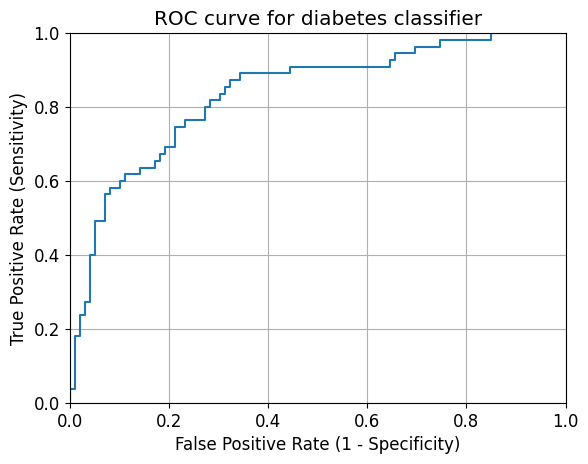

In [57]:
%matplotlib inline
import matplotlib.pyplot as plt



# IMPORTANT: first argument is true values, second argument is predicted probabilities

# we pass y_test and y_pred_prob

y_pred_prob = nb.predict_proba(X_test)[:, 1]

# we do not use y_pred_class, because it will give incorrect results without generating an error
# roc_curve returns 3 objects fpr, tpr, thresholds
# fpr: false positive rate
# tpr: true positive rate
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.title('ROC curve for diabetes classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

**AUC**: the percentage of the ROC plot that is underneath the curve:
* AUC is useful as a single number summary of classifier performance
* Higher value = better classifier
* If you randomly chose one positive and one negative observation, AUC represents the likelihood that your classifier will assign a higher predicted probability to the positive observation

In [58]:
# IMPORTANT: first argument is true values, second argument is predicted probabilities
print(metrics.roc_auc_score(y_test, y_pred_prob))

0.8359963269054177
